# Taller en clase 1 — Procesamiento de Lenguaje Natural

## Objetivo

Construir un pipeline básico de PLN **sin vectores semánticos**, enfocado en:

1. Limpieza y normalización.
2. Corrección básica de términos.
3. Tokenización.
4. Eliminación de palabras poco informativas.
5. Lematización.
6. Reconocimiento de partes de la oración (POS).
7. Reconocimiento de entidades.
8. Extracción de términos relevantes.
9. Comparación léxica entre asignaturas.
10. Construcción de una red de nodos y aristas para responder:

> **¿Cuáles son los temas que comparten las asignaturas?**

El notebook está diseñado para trabajar con `datos_finales.csv`.


## 0. Instalación de librerías

> En Google Colab, ejecutar esta celda una sola vez.  
> Si se trabaja localmente y ya están instaladas las dependencias, puede omitirse.


In [1]:
# Instalación de dependencias
%pip install -q pandas matplotlib networkx spacy symspellpy wordfreq

# Modelo de español de spaCy
import spacy
from spacy.cli import download

try:
    nlp = spacy.load("es_core_news_sm")
except OSError:
    download("es_core_news_sm")
    nlp = spacy.load("es_core_news_sm")

print("Entorno listo.")


Entorno listo.


## 1. Importación de librerías y configuración

In [2]:
import re
import unicodedata
import itertools
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import spacy

from symspellpy import SymSpell, Verbosity
from wordfreq import top_n_list, zipf_frequency

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

try:
    nlp
except NameError:
    nlp = spacy.load("es_core_news_sm")

print("spaCy:", spacy.__version__)


spaCy: 3.8.15


## 2. Carga y diagnóstico de la base

La unidad observada es un registro de tema asociado a una asignatura.  
Antes del procesamiento se revisan dimensiones, valores faltantes, duplicados y categorías de `asignatura`.


In [3]:
# Busca el archivo en ubicaciones comunes de Colab/Jupyter
rutas = [
    "datos_finales.csv",
    "/content/datos_finales.csv",
    "/mnt/data/datos_finales.csv",
]

RUTA = next((r for r in rutas if __import__("os").path.exists(r)), None)

if RUTA is None:
    raise FileNotFoundError(
        "No se encontró datos_finales.csv. Súbelo al entorno o ajusta la variable RUTA."
    )

df = pd.read_csv(RUTA)

print("Dimensión:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nNulos:")
display(df.isna().sum().to_frame("nulos"))

print("\nAsignaturas originales:")
display(df["asignatura"].value_counts(dropna=False).to_frame("registros"))

print("\nPrimeros registros:")
display(df.head(10))


Dimensión: (3277, 2)

Columnas: ['TEMA', 'asignatura']

Nulos:


,nulos
TEMA,1
asignatura,0



Asignaturas originales:


,registros
asignatura,
Asignatura 10,745
Asignatura 1,540
Asignatura 7,497
Asignatura 9,485
Asignatura 4,279
Asignatura 2,245
Asignatura 3,198
Asignatura 6,130
Asignatura 5,111



Primeros registros:


,TEMA,asignatura
0,Actividad integradora - demencia,Asignatura 9
1,Mecanica cardiaca,Asignatura 1
2,Cardiopatía isquémica (Patologia-Md Interna )Meek,Asignatura 4
3,Presentación póster de políticas,Asignatura 9
4,Presentación de protocolos,Asignatura 3
5,Mecanismos para reemplazar la función del páncreas endocrino,Asignatura 4
6,Generalidades de plexos y dermatomas,Asignatura 9
7,Disfagia / Trastorno de la motilidad gastrointestinal\r\n,Asignatura 5
8,Histología funcional intestinal,Asignatura 5
9,Taller de entrevista clínica. Grupo viernes,Asignatura 2


### 2.1 Limpieza estructural

En la base aparece la etiqueta `Asignatua 4`, que corresponde a un error tipográfico de `Asignatura 4`.  
También se eliminan registros sin tema y duplicados exactos `TEMA`–`asignatura`, porque repetir exactamente el mismo tema dentro de la misma asignatura distorsionaría los conteos de términos compartidos.


In [4]:
df = df.copy()

# Normalización de nombres de columnas
df.columns = [c.strip() for c in df.columns]

# Eliminar registros sin tema o sin asignatura
df = df.dropna(subset=["TEMA", "asignatura"])

# Limpiar espacios
df["TEMA"] = df["TEMA"].astype(str).str.strip()
df["asignatura"] = df["asignatura"].astype(str).str.strip()

# Corrección estructural observada en la base
df["asignatura"] = df["asignatura"].replace({
    "Asignatua 4": "Asignatura 4"
})

# Eliminar temas vacíos
df = df[df["TEMA"].ne("")].copy()

# Eliminar duplicados exactos dentro de la misma asignatura
n_antes = len(df)
##df = df.drop_duplicates(subset=["TEMA", "asignatura"]).reset_index(drop=True)
n_despues = len(df)

print(f"Registros antes de quitar duplicados: {n_antes:,}")
print(f"Registros después: {n_despues:,}")
print(f"Duplicados eliminados: {n_antes - n_despues:,}")
print(f"Asignaturas finales: {df['asignatura'].nunique()}")

display(df["asignatura"].value_counts().sort_index().to_frame("temas_unicos"))

Registros antes de quitar duplicados: 3,276
Registros después: 3,276
Duplicados eliminados: 0
Asignaturas finales: 9


,temas_unicos
asignatura,
Asignatura 1,540
Asignatura 10,744
Asignatura 2,245
Asignatura 3,198
Asignatura 4,326
Asignatura 5,111
Asignatura 6,130
Asignatura 7,497
Asignatura 9,485


In [5]:
print("Valores nulos en cada columna:")
display(df.isnull().sum())

Valores nulos en cada columna:


,0
TEMA,0
asignatura,0


## 3. Normalización sintáctica del texto

Se normalizan:

- mayúsculas/minúsculas;
- espacios;
- guiones y separadores;
- caracteres no alfabéticos;
- tildes **sin eliminarlas**, porque son lingüísticamente útiles en español.

No se utilizan embeddings ni representaciones vectoriales semánticas.


In [6]:
def normalizar_texto(texto):
    texto = unicodedata.normalize("NFKC", str(texto))
    texto = texto.lower().strip()

    # Separadores frecuentes
    texto = re.sub(r"[_/|]+", " ", texto)
    texto = re.sub(r"[-–—]+", " ", texto)

    # Conserva letras españolas y espacios
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto, flags=re.IGNORECASE)
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

df["tema_normalizado"] = df["TEMA"].apply(normalizar_texto)

display(df[["TEMA", "tema_normalizado", "asignatura"]].head(15))


,TEMA,tema_normalizado,asignatura
0,Actividad integradora - demencia,actividad integradora demencia,Asignatura 9
1,Mecanica cardiaca,mecanica cardiaca,Asignatura 1
2,Cardiopatía isquémica (Patologia-Md Interna )Meek,cardiopatía isquémica patologia md interna meek,Asignatura 4
3,Presentación póster de políticas,presentación póster de políticas,Asignatura 9
4,Presentación de protocolos,presentación de protocolos,Asignatura 3
5,Mecanismos para reemplazar la función del páncreas endocrino,mecanismos para reemplazar la función del páncreas endocrino,Asignatura 4
6,Generalidades de plexos y dermatomas,generalidades de plexos y dermatomas,Asignatura 9
7,Disfagia / Trastorno de la motilidad gastrointestinal,disfagia trastorno de la motilidad gastrointestinal,Asignatura 5
8,Histología funcional intestinal,histología funcional intestinal,Asignatura 5
9,Taller de entrevista clínica. Grupo viernes,taller de entrevista clínica grupo viernes,Asignatura 2


## 4. Corrección de términos con SymSpell

La corrección ortográfica debe ser conservadora porque el corpus contiene vocabulario técnico.  
Para evitar reemplazar términos biomédicos válidos:

- se construye un diccionario general de español con `wordfreq`;
- se agregan al diccionario términos suficientemente frecuentes del propio corpus;
- solo se corrigen tokens alfabéticos relativamente largos;
- una corrección se acepta únicamente cuando SymSpell encuentra una alternativa a distancia de edición pequeña.

Esto es una corrección **léxica**, no semántica.


In [7]:
# Construcción del diccionario SymSpell
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

# Vocabulario general del español
for palabra in top_n_list("es", 50000):
    freq = max(1, int(10 ** max(0, zipf_frequency(palabra, "es"))))
    sym_spell.create_dictionary_entry(palabra, freq)

# Proteger vocabulario recurrente del propio corpus
tokens_corpus = re.findall(
    r"[a-záéíóúüñ]+",
    " ".join(df["tema_normalizado"].tolist()),
    flags=re.IGNORECASE
)
freq_corpus = Counter(tokens_corpus)

# Los términos que aparecen 2+ veces se consideran parte plausible del vocabulario del curso
for palabra, freq in freq_corpus.items():
    if len(palabra) >= 3 and freq >= 2:
        sym_spell.create_dictionary_entry(palabra, max(1000, freq * 1000))

def corregir_token(token):
    # No corregir tokens muy cortos
    if len(token) < 5:
        return token

    sugerencias = sym_spell.lookup(
        token,
        Verbosity.TOP,
        max_edit_distance=1,
        include_unknown=True
    )

    if not sugerencias:
        return token

    candidato = sugerencias[0].term
    return candidato

def corregir_texto(texto):
    tokens = texto.split()
    corregidos = [corregir_token(t) for t in tokens]
    return " ".join(corregidos)

df["tema_corregido"] = df["tema_normalizado"].apply(corregir_texto)

# Mostrar solo casos donde hubo cambio
cambios = df.loc[
    df["tema_normalizado"] != df["tema_corregido"],
    ["TEMA", "tema_normalizado", "tema_corregido", "asignatura"]
].copy()

print("Registros con algún cambio de corrección:", len(cambios))
display(cambios.head(25))


Registros con algún cambio de corrección: 90


,TEMA,tema_normalizado,tema_corregido,asignatura
6,Generalidades de plexos y dermatomas,generalidades de plexos y dermatomas,generalidades de plenos y dermatomas,Asignatura 9
35,Ayudas diagnósticas en nefrología,ayudas diagnósticas en nefrología,ayudas diagnósticas en neurología,Asignatura 10
133,Intervenión de la función tiroidea,intervenión de la función tiroidea,intervención de la función tiroides,Asignatura 1
160,CEREMONIA DE BATAS,ceremonia de batas,ceremonia de bajas,Asignatura 10
163,Anatomía de la glándula mamaria y Patología benigna de la mama / tamización de cáncer,anatomía de la glándula mamaria y patología benigna de la mama tamización de cáncer,anatomía de la glándula mamarias y patología benigna de la mama tamización de cáncer,Asignatura 7
188,Retículo endoplásmico rugoso,retículo endoplásmico rugoso,retículo endoplásmico jugoso,Asignatura 1
190,"Genes del sistema ligando receptor / señales autocrinas, paracrinas y endocrinas",genes del sistema ligando receptor señales autocrinas paracrinas y endocrinas,genes del sistema ligando receptor señales autocrinas paracrinas y endocrinos,Asignatura 1
207,Región anterior de cuello musculos supra e infrahiodeos,región anterior de cuello musculos supra e infrahiodeos,región anterior de cuello musculo supra e infrahiodeos,Asignatura 4
232,Hidrodinámica corporal: fenómenos sistémicos,hidrodinámica corporal fenómenos sistémicos,hidrodinámica corporal fenómenos sistémicas,Asignatura 1
357,C-SM Enfermedad neoplásica prevalente de hígado y vías biliares,c sm enfermedad neoplásica prevalente de hígado y vías biliares,c sm enfermedad neoplásica prevalentes de hígado y vías biliares,Asignatura 5


## 5. Tokenización, lematización, POS y entidades con spaCy

spaCy permite ejecutar varias etapas sintácticas en un único análisis:

- **Tokenización:** separación del texto en unidades.
- **Lematización:** reducción de una palabra a su forma base.
- **POS tagging:** identificación de sustantivos, adjetivos, verbos, etc.
- **NER:** reconocimiento de entidades nombradas cuando el modelo las identifica.

Para la red temática se priorizan **sustantivos, nombres propios y adjetivos**, porque tienden a aportar más información temática que artículos, preposiciones o verbos auxiliares.


In [8]:
# Palabras adicionales poco informativas para este corpus.
# Se pueden ampliar después de inspeccionar resultados.
STOP_EXTRA = {
    "tema", "clase", "sesion", "sesión", "actividad", "taller",
    "presentacion", "presentación", "introduccion", "introducción",
    "general", "parte", "caso", "casos", "revision", "revisión"
}

POS_RELEVANTES = {"NOUN", "PROPN", "ADJ"}

def analizar_spacy(texto):
    doc = nlp(texto)

    tokens = [tok.text for tok in doc if not tok.is_space]

    pos = [(tok.text, tok.pos_) for tok in doc if not tok.is_space]

    entidades = [(ent.text, ent.label_) for ent in doc.ents]

    terminos = []
    for tok in doc:
        lemma = tok.lemma_.lower().strip()

        if (
            tok.is_alpha
            and not tok.is_stop
            and tok.pos_ in POS_RELEVANTES
            and len(lemma) >= 3
            and lemma not in STOP_EXTRA
        ):
            terminos.append(lemma)

    # Sin repetidos dentro de un mismo tema
    terminos = list(dict.fromkeys(terminos))

    return tokens, pos, entidades, terminos

resultados = df["tema_corregido"].apply(analizar_spacy)

df["tokens"] = resultados.apply(lambda x: x[0])
df["pos"] = resultados.apply(lambda x: x[1])
df["entidades"] = resultados.apply(lambda x: x[2])
df["terminos_relevantes"] = resultados.apply(lambda x: x[3])

display(
    df[[
        "TEMA", "tema_corregido", "tokens", "pos",
        "entidades", "terminos_relevantes", "asignatura"
    ]].head(15)
)


,TEMA,tema_corregido,tokens,pos,entidades,terminos_relevantes,asignatura
0,Actividad integradora - demencia,actividad integradora demencia,"[actividad, integradora, demencia]","[(actividad, NOUN), (integradora, ADJ), (demencia, NOUN)]",[],"[integrador, demencia]",Asignatura 9
1,Mecanica cardiaca,mecanica cardiaca,"[mecanica, cardiaca]","[(mecanica, ADJ), (cardiaca, ADJ)]",[],"[mecanico, cardiaco]",Asignatura 1
2,Cardiopatía isquémica (Patologia-Md Interna )Meek,cardiopatía isquémica patologia md interna meek,"[cardiopatía, isquémica, patologia, md, interna, meek]","[(cardiopatía, NOUN), (isquémica, ADJ), (patologia, NOUN), (md, PROPN), (interna, ADJ), (meek, VERB)]",[],"[cardiopatía, isquémico, patologia, interno]",Asignatura 4
3,Presentación póster de políticas,presentación póster de políticas,"[presentación, póster, de, políticas]","[(presentación, NOUN), (póster, VERB), (de, ADP), (políticas, NOUN)]","[(presentación, PER)]",[política],Asignatura 9
4,Presentación de protocolos,presentación de protocolos,"[presentación, de, protocolos]","[(presentación, NOUN), (de, ADP), (protocolos, NOUN)]","[(presentación de protocolos, MISC)]",[protocolo],Asignatura 3
5,Mecanismos para reemplazar la función del páncreas endocrino,mecanismos para reemplazar la función del páncreas endocrino,"[mecanismos, para, reemplazar, la, función, del, páncreas, endocrino]","[(mecanismos, NOUN), (para, ADP), (reemplazar, VERB), (la, DET), (función, NOUN), (del, ADP), (páncreas, NOUN), (end...",[],"[mecanismo, función, páncrea, endocrino]",Asignatura 4
6,Generalidades de plexos y dermatomas,generalidades de plenos y dermatomas,"[generalidades, de, plenos, y, dermatomas]","[(generalidades, NOUN), (de, ADP), (plenos, NOUN), (y, CCONJ), (dermatomas, ADJ)]",[],"[generalidad, pleno, dermatoma]",Asignatura 9
7,Disfagia / Trastorno de la motilidad gastrointestinal,disfagia trastorno de la motilidad gastrointestinal,"[disfagia, trastorno, de, la, motilidad, gastrointestinal]","[(disfagia, NOUN), (trastorno, ADJ), (de, ADP), (la, DET), (motilidad, NOUN), (gastrointestinal, ADJ)]",[],"[disfagia, trastorno, motilidad, gastrointestinal]",Asignatura 5
8,Histología funcional intestinal,histología funcional intestinal,"[histología, funcional, intestinal]","[(histología, NOUN), (funcional, ADJ), (intestinal, ADJ)]",[],"[histología, funcional, intestinal]",Asignatura 5
9,Taller de entrevista clínica. Grupo viernes,taller de entrevista clínica grupo viernes,"[taller, de, entrevista, clínica, grupo, viernes]","[(taller, NOUN), (de, ADP), (entrevista, NOUN), (clínica, ADJ), (grupo, NOUN), (viernes, NOUN)]",[],"[entrevista, clínico, grupo, viernes]",Asignatura 2


## 6. Ejemplo completo del pipeline

Esta tabla sirve directamente como evidencia para el README y la presentación.


In [9]:
ejemplo_pipeline = df[[
    "TEMA",
    "tema_normalizado",
    "tema_corregido",
    "tokens",
    "pos",
    "entidades",
    "terminos_relevantes",
    "asignatura"
]].head(12)

display(ejemplo_pipeline)


,TEMA,tema_normalizado,tema_corregido,tokens,pos,entidades,terminos_relevantes,asignatura
0,Actividad integradora - demencia,actividad integradora demencia,actividad integradora demencia,"[actividad, integradora, demencia]","[(actividad, NOUN), (integradora, ADJ), (demencia, NOUN)]",[],"[integrador, demencia]",Asignatura 9
1,Mecanica cardiaca,mecanica cardiaca,mecanica cardiaca,"[mecanica, cardiaca]","[(mecanica, ADJ), (cardiaca, ADJ)]",[],"[mecanico, cardiaco]",Asignatura 1
2,Cardiopatía isquémica (Patologia-Md Interna )Meek,cardiopatía isquémica patologia md interna meek,cardiopatía isquémica patologia md interna meek,"[cardiopatía, isquémica, patologia, md, interna, meek]","[(cardiopatía, NOUN), (isquémica, ADJ), (patologia, NOUN), (md, PROPN), (interna, ADJ), (meek, VERB)]",[],"[cardiopatía, isquémico, patologia, interno]",Asignatura 4
3,Presentación póster de políticas,presentación póster de políticas,presentación póster de políticas,"[presentación, póster, de, políticas]","[(presentación, NOUN), (póster, VERB), (de, ADP), (políticas, NOUN)]","[(presentación, PER)]",[política],Asignatura 9
4,Presentación de protocolos,presentación de protocolos,presentación de protocolos,"[presentación, de, protocolos]","[(presentación, NOUN), (de, ADP), (protocolos, NOUN)]","[(presentación de protocolos, MISC)]",[protocolo],Asignatura 3
5,Mecanismos para reemplazar la función del páncreas endocrino,mecanismos para reemplazar la función del páncreas endocrino,mecanismos para reemplazar la función del páncreas endocrino,"[mecanismos, para, reemplazar, la, función, del, páncreas, endocrino]","[(mecanismos, NOUN), (para, ADP), (reemplazar, VERB), (la, DET), (función, NOUN), (del, ADP), (páncreas, NOUN), (end...",[],"[mecanismo, función, páncrea, endocrino]",Asignatura 4
6,Generalidades de plexos y dermatomas,generalidades de plexos y dermatomas,generalidades de plenos y dermatomas,"[generalidades, de, plenos, y, dermatomas]","[(generalidades, NOUN), (de, ADP), (plenos, NOUN), (y, CCONJ), (dermatomas, ADJ)]",[],"[generalidad, pleno, dermatoma]",Asignatura 9
7,Disfagia / Trastorno de la motilidad gastrointestinal,disfagia trastorno de la motilidad gastrointestinal,disfagia trastorno de la motilidad gastrointestinal,"[disfagia, trastorno, de, la, motilidad, gastrointestinal]","[(disfagia, NOUN), (trastorno, ADJ), (de, ADP), (la, DET), (motilidad, NOUN), (gastrointestinal, ADJ)]",[],"[disfagia, trastorno, motilidad, gastrointestinal]",Asignatura 5
8,Histología funcional intestinal,histología funcional intestinal,histología funcional intestinal,"[histología, funcional, intestinal]","[(histología, NOUN), (funcional, ADJ), (intestinal, ADJ)]",[],"[histología, funcional, intestinal]",Asignatura 5
9,Taller de entrevista clínica. Grupo viernes,taller de entrevista clínica grupo viernes,taller de entrevista clínica grupo viernes,"[taller, de, entrevista, clínica, grupo, viernes]","[(taller, NOUN), (de, ADP), (entrevista, NOUN), (clínica, ADJ), (grupo, NOUN), (viernes, NOUN)]",[],"[entrevista, clínico, grupo, viernes]",Asignatura 2


## 7. Términos más frecuentes por asignatura

Primero se expande la lista de términos relevantes para estudiar frecuencias léxicas.


In [10]:
terminos_long = (
    df[["asignatura", "terminos_relevantes"]]
    .explode("terminos_relevantes")
    .dropna()
    .rename(columns={"terminos_relevantes": "termino"})
)

freq_asignatura = (
    terminos_long
    .groupby(["asignatura", "termino"])
    .size()
    .reset_index(name="frecuencia")
    .sort_values(["asignatura", "frecuencia"], ascending=[True, False])
)

top_10_por_asignatura = (
    freq_asignatura
    .groupby("asignatura", group_keys=False)
    .head(10)
)

display(top_10_por_asignatura)


,asignatura,termino,frecuencia
154,Asignatura 1,evaluación,42
366,Asignatura 1,sistema,34
252,Asignatura 1,laboratorio,28
309,Asignatura 1,oral,23
32,Asignatura 1,biológico,20
45,Asignatura 1,cardiovascular,20
218,Asignatura 1,histología,20
12,Asignatura 1,anfiteatro,18
370,Asignatura 1,social,18
126,Asignatura 1,enfermedad,17


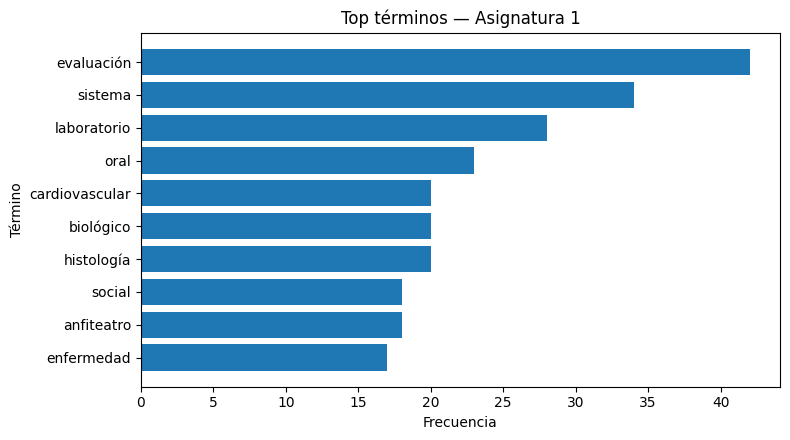

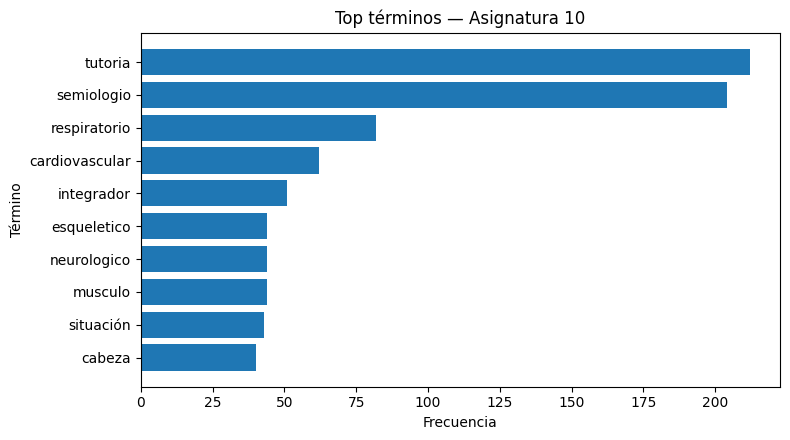

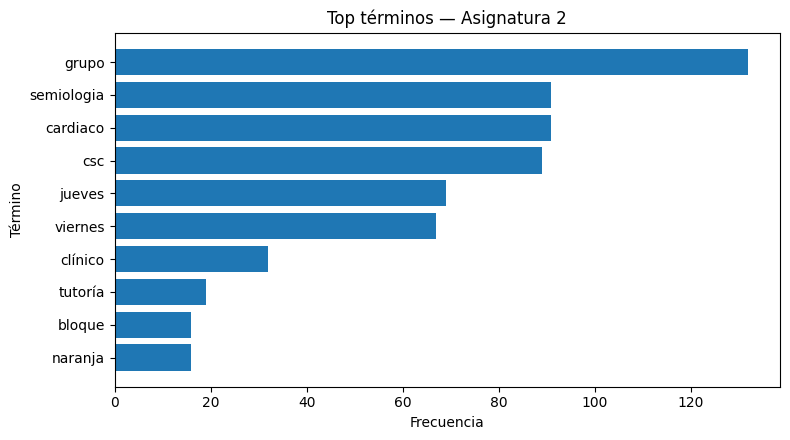

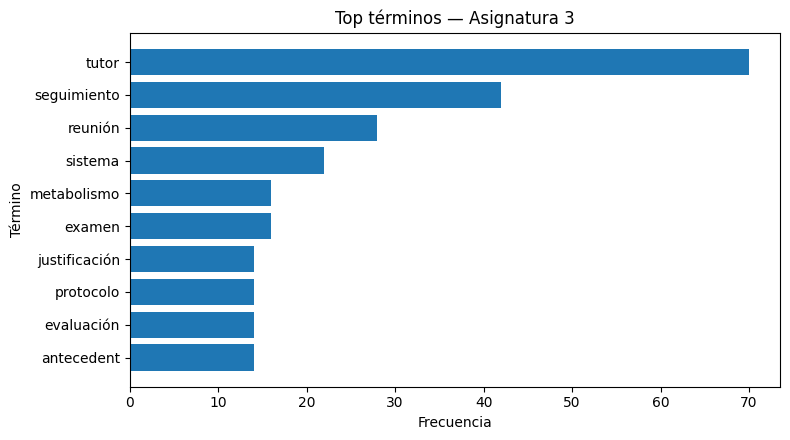

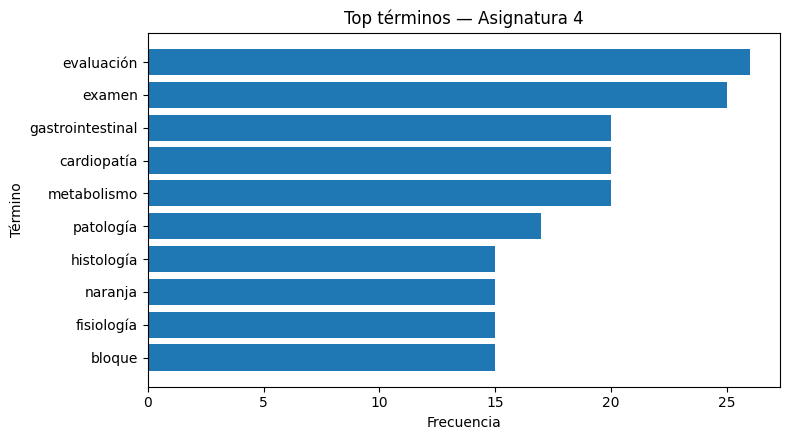

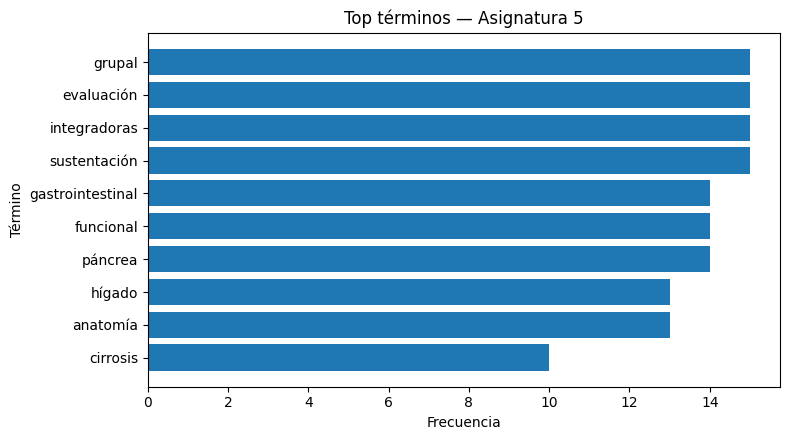

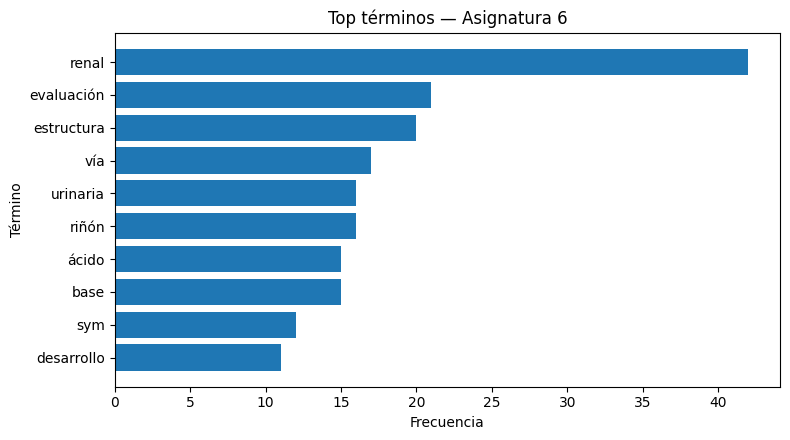

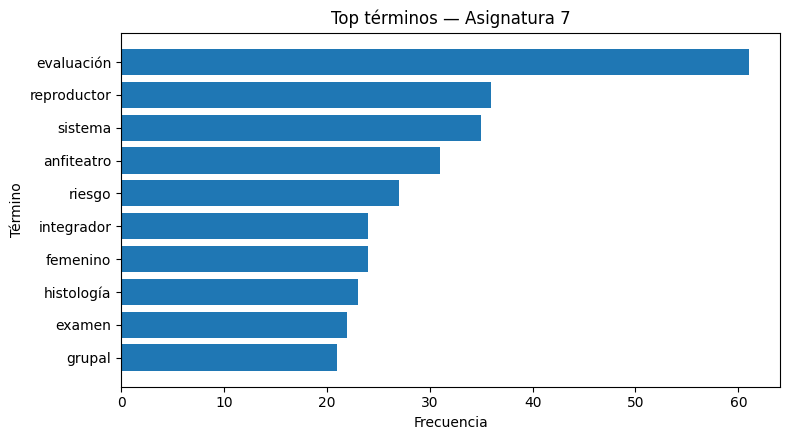

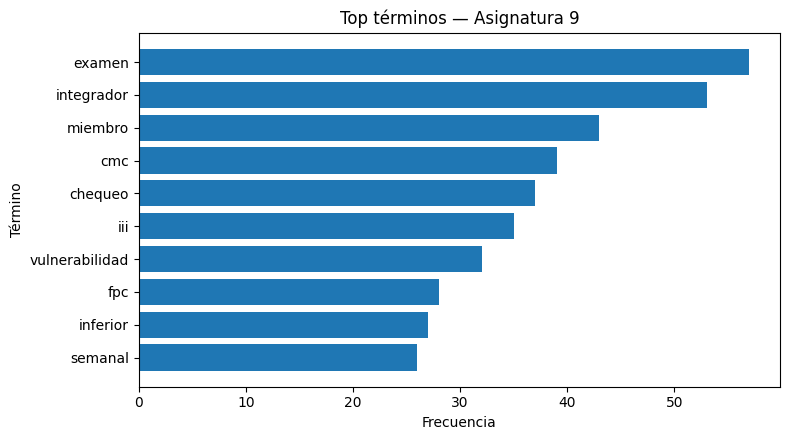

In [11]:
# Visualización de los 10 términos principales de cada asignatura
for asignatura, sub in top_10_por_asignatura.groupby("asignatura"):
    sub = sub.sort_values("frecuencia")
    plt.figure(figsize=(8, 4.5))
    plt.barh(sub["termino"], sub["frecuencia"])
    plt.title(f"Top términos — {asignatura}")
    plt.xlabel("Frecuencia")
    plt.ylabel("Término")
    plt.tight_layout()
    plt.show()


## 8. Temas compartidos entre asignaturas

Para evitar que términos muy comunes dominen la comparación, un término se considera parte del vocabulario de una asignatura si aparece al menos `MIN_FREQ_TERMINO` veces.

El análisis es estrictamente **léxico**: dos asignaturas comparten un término cuando, después de normalización y lematización, aparece la misma forma léxica en ambas.


In [12]:
MIN_FREQ_TERMINO = 2

vocab_por_asignatura = {}

for asignatura, sub in freq_asignatura.groupby("asignatura"):
    vocab = set(
        sub.loc[sub["frecuencia"] >= MIN_FREQ_TERMINO, "termino"]
    )
    vocab_por_asignatura[asignatura] = vocab

resumen_vocab = pd.DataFrame({
    "asignatura": list(vocab_por_asignatura.keys()),
    "n_terminos": [len(v) for v in vocab_por_asignatura.values()]
}).sort_values("asignatura")

display(resumen_vocab)


,asignatura,n_terminos
0,Asignatura 1,249
1,Asignatura 10,234
2,Asignatura 2,74
3,Asignatura 3,49
4,Asignatura 4,153
5,Asignatura 5,67
6,Asignatura 6,88
7,Asignatura 7,267
8,Asignatura 9,187


In [13]:
# Comparación por pares
filas = []

for a, b in itertools.combinations(sorted(vocab_por_asignatura), 2):
    va = vocab_por_asignatura[a]
    vb = vocab_por_asignatura[b]

    compartidos = sorted(va & vb)
    union = va | vb

    # Jaccard es una similitud entre conjuntos de términos, no un vector semántico.
    jaccard = len(compartidos) / len(union) if union else 0

    filas.append({
        "asignatura_a": a,
        "asignatura_b": b,
        "n_compartidos": len(compartidos),
        "jaccard_lexico": jaccard,
        "terminos_compartidos": ", ".join(compartidos)
    })

pares = (
    pd.DataFrame(filas)
    .sort_values(["n_compartidos", "jaccard_lexico"], ascending=False)
    .reset_index(drop=True)
)

display(pares.head(20))


,asignatura_a,asignatura_b,n_compartidos,jaccard_lexico,terminos_compartidos
0,Asignatura 7,Asignatura 9,63,0.161125,"alteración, anatomía, anfiteatro, aspecto, basal, cerebral, chequeo, clínico, cmc, comunicación, configuración, cont..."
1,Asignatura 10,Asignatura 7,54,0.120805,"abdominal, abordaje, agudo, anciano, basado, blando, clínico, control, correlación, corte, crónico, desarrollo, diag..."
2,Asignatura 1,Asignatura 7,54,0.116883,"administración, agudo, anfiteatro, aparato, cavidad, celular, circulación, comunicación, común, cáncer, digestivo, d..."
3,Asignatura 6,Asignatura 7,48,0.156352,"abordaje, aspecto, control, cáncer, desarrollo, eje, enfermedad, escrito, eval, evaluación, farmacocinético, funcion..."
4,Asignatura 4,Asignatura 7,48,0.129032,"anatomía, anfiteatro, bioquímica, cavidad, clínico, delgado, desarrollo, digestivo, endocrino, estudio, estómago, es..."
5,Asignatura 1,Asignatura 4,44,0.122905,"anfiteatro, arritmia, biomolécula, cardiaco, cardiovascular, cavidad, congénita, corporal, cuello, digestivo, endocr..."
6,Asignatura 1,Asignatura 10,42,0.095238,"agudo, artificial, cardiaco, cardio, cardiovascular, cuello, cuidado, curso, dolor, edo, eléctrico, endocrino, enfer..."
7,Asignatura 1,Asignatura 9,35,0.087282,"anfiteatro, artificial, base, biológico, comunicación, endocrino, espacio, estructura, evaluación, examen, fisiologí..."
8,Asignatura 4,Asignatura 5,34,0.182796,"anatomía, bajo, digestivo, disfagia, evaluación, funcional, función, gastrointestinal, glucós, hematemesis, hematoqu..."
9,Asignatura 5,Asignatura 7,31,0.102310,"anatomía, aspecto, control, digestivo, enfermedad, evaluación, farmacocinético, funcional, función, glándula, grupal..."


## 9. Términos compartidos por varias asignaturas

Este ranking permite identificar los conceptos que conectan transversalmente el plan de estudios.


In [14]:
asignaturas_por_termino = defaultdict(set)

for asignatura, vocab in vocab_por_asignatura.items():
    for termino in vocab:
        asignaturas_por_termino[termino].add(asignatura)

temas_transversales = pd.DataFrame([
    {
        "termino": termino,
        "n_asignaturas": len(asigs),
        "asignaturas": ", ".join(sorted(asigs))
    }
    for termino, asigs in asignaturas_por_termino.items()
    if len(asigs) >= 2
]).sort_values(["n_asignaturas", "termino"], ascending=[False, True])

display(temas_transversales.head(50))


,termino,n_asignaturas,asignaturas
25,evaluación,9,"Asignatura 1, Asignatura 10, Asignatura 2, Asignatura 3, Asignatura 4, Asignatura 5, Asignatura 6, Asignatura 7, Asi..."
34,vía,8,"Asignatura 1, Asignatura 10, Asignatura 2, Asignatura 4, Asignatura 5, Asignatura 6, Asignatura 7, Asignatura 9"
111,examen,7,"Asignatura 1, Asignatura 10, Asignatura 2, Asignatura 3, Asignatura 4, Asignatura 7, Asignatura 9"
76,oral,7,"Asignatura 1, Asignatura 10, Asignatura 2, Asignatura 3, Asignatura 4, Asignatura 5, Asignatura 7"
98,patología,7,"Asignatura 1, Asignatura 10, Asignatura 4, Asignatura 5, Asignatura 6, Asignatura 7, Asignatura 9"
37,sistema,7,"Asignatura 1, Asignatura 2, Asignatura 3, Asignatura 4, Asignatura 6, Asignatura 7, Asignatura 9"
165,anatomía,6,"Asignatura 2, Asignatura 3, Asignatura 4, Asignatura 5, Asignatura 7, Asignatura 9"
79,enfermedad,6,"Asignatura 1, Asignatura 10, Asignatura 3, Asignatura 5, Asignatura 6, Asignatura 7"
41,función,6,"Asignatura 1, Asignatura 4, Asignatura 5, Asignatura 6, Asignatura 7, Asignatura 9"
28,histología,6,"Asignatura 1, Asignatura 2, Asignatura 4, Asignatura 5, Asignatura 7, Asignatura 9"


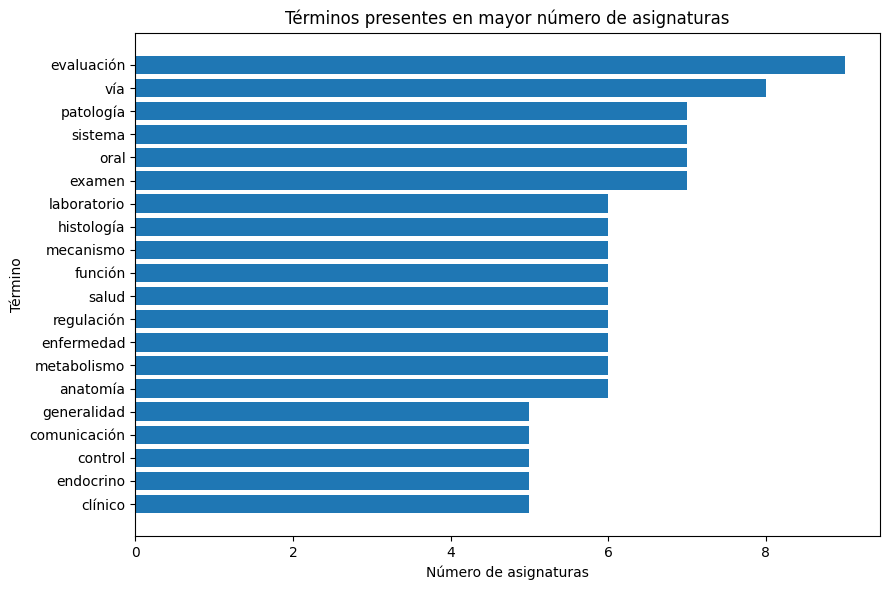

In [15]:
top_transversales = temas_transversales.head(20).sort_values("n_asignaturas")

plt.figure(figsize=(9, 6))
plt.barh(top_transversales["termino"], top_transversales["n_asignaturas"])
plt.title("Términos presentes en mayor número de asignaturas")
plt.xlabel("Número de asignaturas")
plt.ylabel("Término")
plt.tight_layout()
plt.show()


## 10. Matriz de similitud léxica entre asignaturas

Se utiliza el índice de **Jaccard**:

\[
J(A,B)=\frac{|A \cap B|}{|A \cup B|}
\]

donde `A` y `B` son los conjuntos de términos relevantes de dos asignaturas.

Esta medida **no utiliza significado semántico ni embeddings**; solo compara coincidencias léxicas después de la normalización.


,Asignatura 1,Asignatura 10,Asignatura 2,Asignatura 3,Asignatura 4,Asignatura 5,Asignatura 6,Asignatura 7,Asignatura 9
Asignatura 1,1.000,0.095,0.084,0.057,0.123,0.046,0.066,0.117,0.087
Asignatura 10,0.095,1.000,0.066,0.029,0.084,0.038,0.066,0.121,0.079
Asignatura 2,0.084,0.066,1.000,0.079,0.097,0.044,0.019,0.052,0.074
Asignatura 3,0.057,0.029,0.079,1.000,0.086,0.045,0.030,0.046,0.058
Asignatura 4,0.123,0.084,0.097,0.086,1.000,0.183,0.081,0.129,0.097
Asignatura 5,0.046,0.038,0.044,0.045,0.183,1.000,0.148,0.102,0.054
Asignatura 6,0.066,0.066,0.019,0.030,0.081,0.148,1.000,0.156,0.070
Asignatura 7,0.117,0.121,0.052,0.046,0.129,0.102,0.156,1.000,0.161
Asignatura 9,0.087,0.079,0.074,0.058,0.097,0.054,0.070,0.161,1.000


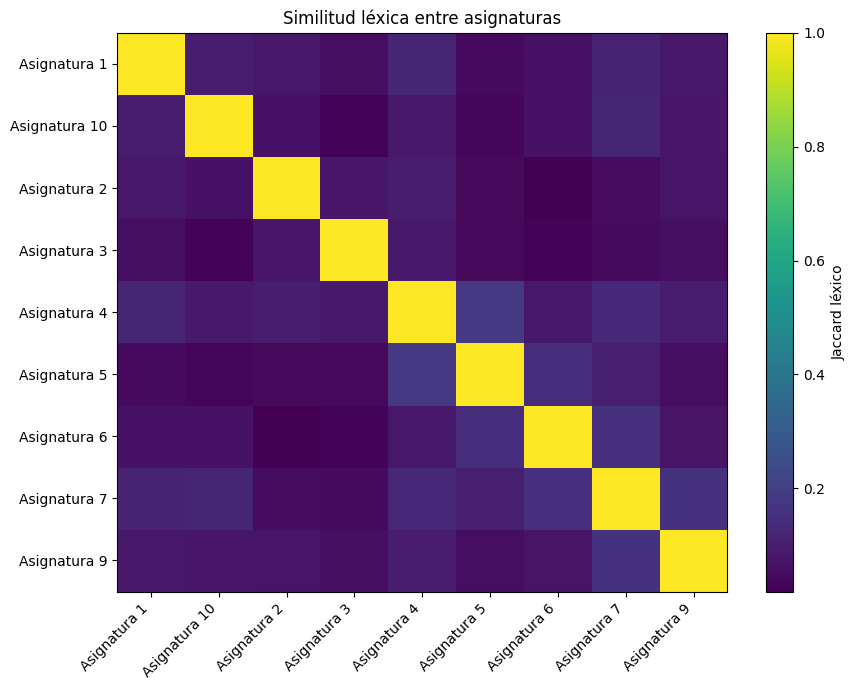

In [16]:
asignaturas = sorted(vocab_por_asignatura.keys())
matriz = pd.DataFrame(0.0, index=asignaturas, columns=asignaturas)

for a in asignaturas:
    for b in asignaturas:
        va = vocab_por_asignatura[a]
        vb = vocab_por_asignatura[b]
        union = va | vb
        matriz.loc[a, b] = len(va & vb) / len(union) if union else 0

display(matriz.round(3))

plt.figure(figsize=(9, 7))
plt.imshow(matriz.values, aspect="auto")
plt.xticks(range(len(asignaturas)), asignaturas, rotation=45, ha="right")
plt.yticks(range(len(asignaturas)), asignaturas)
plt.colorbar(label="Jaccard léxico")
plt.title("Similitud léxica entre asignaturas")
plt.tight_layout()
plt.show()


## 11. Grafo final: asignaturas conectadas por temas compartidos

Cada nodo representa una asignatura.

Una arista conecta dos asignaturas cuando comparten suficientes términos.  
El grosor de la arista representa la cantidad de términos compartidos.

Para mantener una visualización legible se usa un umbral automático basado en la distribución de coincidencias. El valor puede ajustarse manualmente.


Umbral de temas compartidos usado para dibujar una arista: 21
Nodos: 9
Aristas: 15


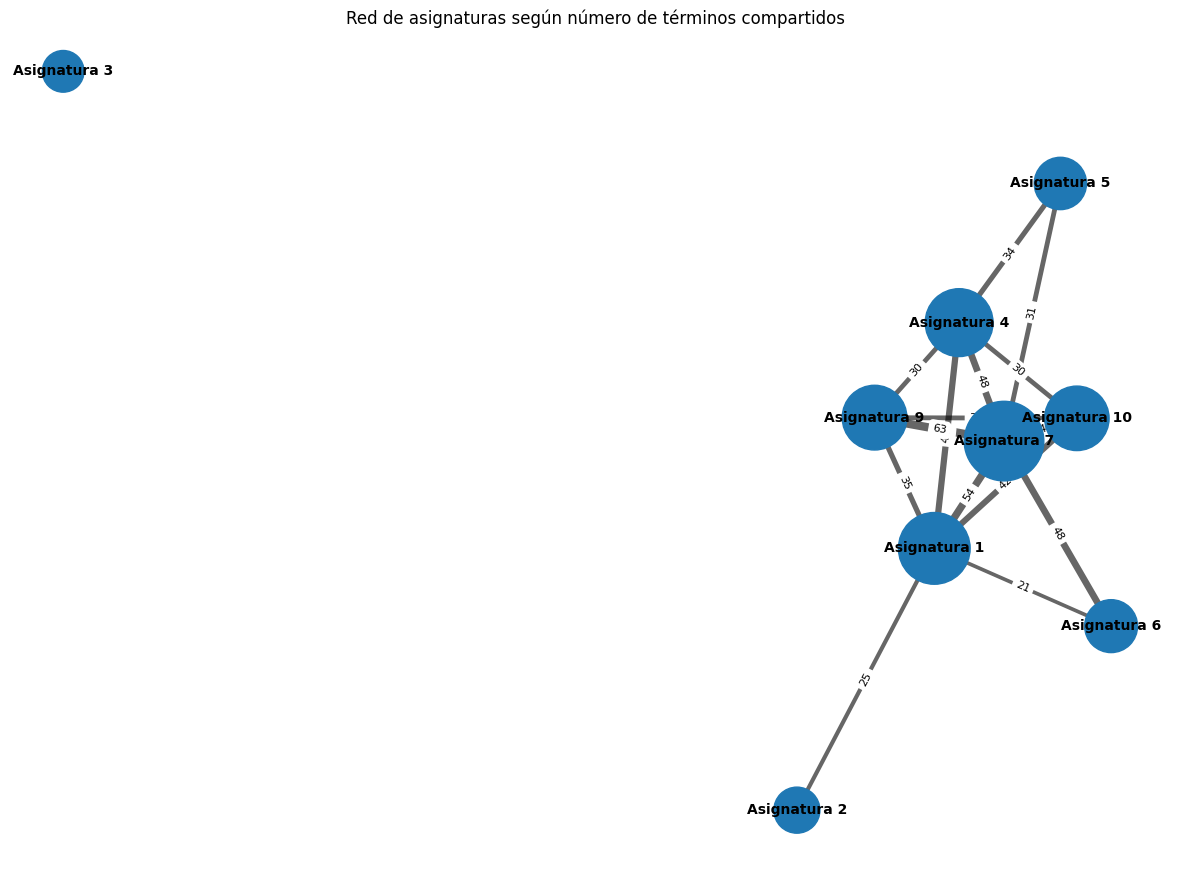

In [17]:
# Umbral automático: percentil 60 entre pares con al menos una coincidencia
positivos = pares.loc[pares["n_compartidos"] > 0, "n_compartidos"]

if len(positivos):
    UMBRAL_ARISTA = max(2, int(np.percentile(positivos, 60)))
else:
    UMBRAL_ARISTA = 1

print("Umbral de temas compartidos usado para dibujar una arista:", UMBRAL_ARISTA)

G = nx.Graph()

for asignatura in asignaturas:
    G.add_node(asignatura)

for _, fila in pares.iterrows():
    if fila["n_compartidos"] >= UMBRAL_ARISTA:
        G.add_edge(
            fila["asignatura_a"],
            fila["asignatura_b"],
            weight=int(fila["n_compartidos"]),
            jaccard=float(fila["jaccard_lexico"])
        )

print("Nodos:", G.number_of_nodes())
print("Aristas:", G.number_of_edges())

plt.figure(figsize=(12, 9))

pos = nx.spring_layout(G, seed=42, k=1.5)

grados = dict(G.degree(weight="weight"))
node_sizes = [900 + 8 * grados.get(n, 0) for n in G.nodes()]

weights = [G[u][v]["weight"] for u, v in G.edges()]
if weights:
    max_w = max(weights)
    edge_widths = [1 + 5 * (w / max_w) for w in weights]
else:
    edge_widths = []

nx.draw_networkx_nodes(G, pos, node_size=node_sizes)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6)

edge_labels = {
    (u, v): G[u][v]["weight"]
    for u, v in G.edges()
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Red de asignaturas según número de términos compartidos")
plt.axis("off")
plt.tight_layout()
plt.savefig("grafo_asignaturas.png", dpi=300, bbox_inches="tight")
plt.show()


## 12. Grafo bipartito: asignaturas y principales términos transversales

La segunda visualización hace explícitos los conceptos que generan las conexiones.

- nodos grandes: asignaturas;
- nodos pequeños: términos;
- aristas: presencia de un término en una asignatura.


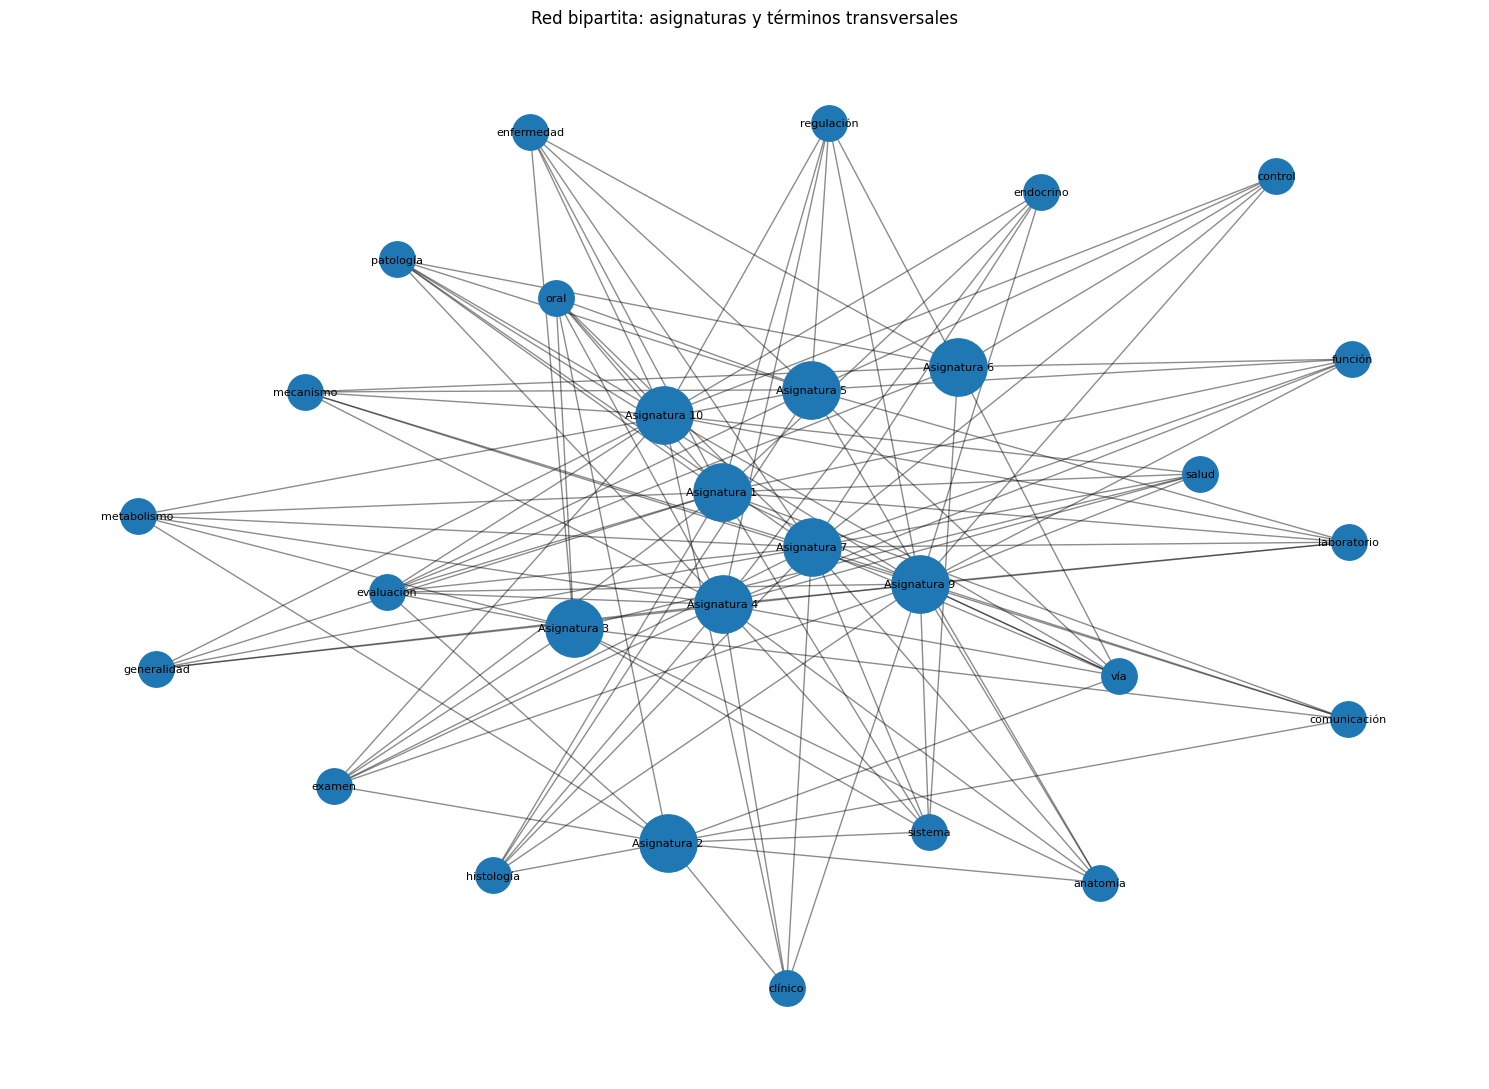

In [18]:
N_TERMINOS_GRAFO = 20

terminos_grafo = temas_transversales.head(N_TERMINOS_GRAFO)["termino"].tolist()

B = nx.Graph()

for asignatura in asignaturas:
    B.add_node(asignatura, tipo="asignatura")

for termino in terminos_grafo:
    B.add_node(termino, tipo="termino")
    for asignatura in sorted(asignaturas_por_termino[termino]):
        B.add_edge(asignatura, termino)

plt.figure(figsize=(15, 11))
pos_b = nx.spring_layout(B, seed=42, k=1.2)

nodos_asig = [n for n, d in B.nodes(data=True) if d["tipo"] == "asignatura"]
nodos_term = [n for n, d in B.nodes(data=True) if d["tipo"] == "termino"]

nx.draw_networkx_nodes(B, pos_b, nodelist=nodos_asig, node_size=1700)
nx.draw_networkx_nodes(B, pos_b, nodelist=nodos_term, node_size=650)
nx.draw_networkx_edges(B, pos_b, alpha=0.45)
nx.draw_networkx_labels(B, pos_b, font_size=8)

plt.title("Red bipartita: asignaturas y términos transversales")
plt.axis("off")
plt.tight_layout()
plt.savefig("grafo_bipartito_temas.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Métricas de la red

Se calculan métricas descriptivas para identificar qué asignaturas funcionan como principales conectores del conjunto.


In [19]:
metricas_red = pd.DataFrame({
    "asignatura": list(G.nodes()),
    "grado": [G.degree(n) for n in G.nodes()],
    "grado_ponderado": [G.degree(n, weight="weight") for n in G.nodes()],
    "centralidad_grado": list(nx.degree_centrality(G).values()) if len(G) > 1 else [0] * len(G)
}).sort_values("grado_ponderado", ascending=False)

display(metricas_red)


,asignatura,grado,grado_ponderado,centralidad_grado
7,Asignatura 7,6,298,0.750
0,Asignatura 1,6,221,0.750
4,Asignatura 4,5,186,0.625
8,Asignatura 9,4,159,0.500
1,Asignatura 10,4,157,0.500
6,Asignatura 6,2,69,0.250
5,Asignatura 5,2,65,0.250
2,Asignatura 2,1,25,0.125
3,Asignatura 3,0,0,0.000


## 14. Resumen automático para responder la pregunta principal

La celda siguiente imprime los hallazgos esenciales que pueden convertirse en los **máximo 3 párrafos** requeridos por el taller.


In [20]:
print("=" * 90)
print("RESULTADOS PRINCIPALES")
print("=" * 90)

print("\n1) Pares de asignaturas con mayor cantidad de términos compartidos:")
display(
    pares[[
        "asignatura_a", "asignatura_b",
        "n_compartidos", "jaccard_lexico",
        "terminos_compartidos"
    ]].head(10)
)

print("\n2) Términos más transversales:")
display(temas_transversales.head(20))

print("\n3) Asignaturas más conectadas en la red:")
display(metricas_red.head(10))

if not pares.empty:
    mejor = pares.iloc[0]
    print(
        f"\nEl par con mayor coincidencia léxica es "
        f"{mejor['asignatura_a']} – {mejor['asignatura_b']}, "
        f"con {int(mejor['n_compartidos'])} términos compartidos."
    )

if not temas_transversales.empty:
    top_terms = ", ".join(temas_transversales.head(10)["termino"].tolist())
    print(f"Los términos más transversales incluyen: {top_terms}.")


RESULTADOS PRINCIPALES

1) Pares de asignaturas con mayor cantidad de términos compartidos:


,asignatura_a,asignatura_b,n_compartidos,jaccard_lexico,terminos_compartidos
0,Asignatura 7,Asignatura 9,63,0.161125,"alteración, anatomía, anfiteatro, aspecto, basal, cerebral, chequeo, clínico, cmc, comunicación, configuración, cont..."
1,Asignatura 10,Asignatura 7,54,0.120805,"abdominal, abordaje, agudo, anciano, basado, blando, clínico, control, correlación, corte, crónico, desarrollo, diag..."
2,Asignatura 1,Asignatura 7,54,0.116883,"administración, agudo, anfiteatro, aparato, cavidad, celular, circulación, comunicación, común, cáncer, digestivo, d..."
3,Asignatura 6,Asignatura 7,48,0.156352,"abordaje, aspecto, control, cáncer, desarrollo, eje, enfermedad, escrito, eval, evaluación, farmacocinético, funcion..."
4,Asignatura 4,Asignatura 7,48,0.129032,"anatomía, anfiteatro, bioquímica, cavidad, clínico, delgado, desarrollo, digestivo, endocrino, estudio, estómago, es..."
5,Asignatura 1,Asignatura 4,44,0.122905,"anfiteatro, arritmia, biomolécula, cardiaco, cardiovascular, cavidad, congénita, corporal, cuello, digestivo, endocr..."
6,Asignatura 1,Asignatura 10,42,0.095238,"agudo, artificial, cardiaco, cardio, cardiovascular, cuello, cuidado, curso, dolor, edo, eléctrico, endocrino, enfer..."
7,Asignatura 1,Asignatura 9,35,0.087282,"anfiteatro, artificial, base, biológico, comunicación, endocrino, espacio, estructura, evaluación, examen, fisiologí..."
8,Asignatura 4,Asignatura 5,34,0.182796,"anatomía, bajo, digestivo, disfagia, evaluación, funcional, función, gastrointestinal, glucós, hematemesis, hematoqu..."
9,Asignatura 5,Asignatura 7,31,0.102310,"anatomía, aspecto, control, digestivo, enfermedad, evaluación, farmacocinético, funcional, función, glándula, grupal..."



2) Términos más transversales:


,termino,n_asignaturas,asignaturas
25,evaluación,9,"Asignatura 1, Asignatura 10, Asignatura 2, Asignatura 3, Asignatura 4, Asignatura 5, Asignatura 6, Asignatura 7, Asi..."
34,vía,8,"Asignatura 1, Asignatura 10, Asignatura 2, Asignatura 4, Asignatura 5, Asignatura 6, Asignatura 7, Asignatura 9"
111,examen,7,"Asignatura 1, Asignatura 10, Asignatura 2, Asignatura 3, Asignatura 4, Asignatura 7, Asignatura 9"
76,oral,7,"Asignatura 1, Asignatura 10, Asignatura 2, Asignatura 3, Asignatura 4, Asignatura 5, Asignatura 7"
98,patología,7,"Asignatura 1, Asignatura 10, Asignatura 4, Asignatura 5, Asignatura 6, Asignatura 7, Asignatura 9"
37,sistema,7,"Asignatura 1, Asignatura 2, Asignatura 3, Asignatura 4, Asignatura 6, Asignatura 7, Asignatura 9"
165,anatomía,6,"Asignatura 2, Asignatura 3, Asignatura 4, Asignatura 5, Asignatura 7, Asignatura 9"
79,enfermedad,6,"Asignatura 1, Asignatura 10, Asignatura 3, Asignatura 5, Asignatura 6, Asignatura 7"
41,función,6,"Asignatura 1, Asignatura 4, Asignatura 5, Asignatura 6, Asignatura 7, Asignatura 9"
28,histología,6,"Asignatura 1, Asignatura 2, Asignatura 4, Asignatura 5, Asignatura 7, Asignatura 9"



3) Asignaturas más conectadas en la red:


,asignatura,grado,grado_ponderado,centralidad_grado
7,Asignatura 7,6,298,0.750
0,Asignatura 1,6,221,0.750
4,Asignatura 4,5,186,0.625
8,Asignatura 9,4,159,0.500
1,Asignatura 10,4,157,0.500
6,Asignatura 6,2,69,0.250
5,Asignatura 5,2,65,0.250
2,Asignatura 2,1,25,0.125
3,Asignatura 3,0,0,0.000



El par con mayor coincidencia léxica es Asignatura 7 – Asignatura 9, con 63 términos compartidos.
Los términos más transversales incluyen: evaluación, vía, examen, oral, patología, sistema, anatomía, enfermedad, función, histología.


## 15. Exportación de resultados

Se guardan tablas y figuras para utilizarlas directamente en el README y en la presentación.


In [21]:
df.to_csv("datos_procesados_pln.csv", index=False)
freq_asignatura.to_csv("frecuencias_por_asignatura.csv", index=False)
pares.to_csv("comparacion_asignaturas.csv", index=False)
temas_transversales.to_csv("temas_transversales.csv", index=False)
metricas_red.to_csv("metricas_red.csv", index=False)
matriz.to_csv("matriz_jaccard.csv")

print("Archivos exportados:")
print("- datos_procesados_pln.csv")
print("- frecuencias_por_asignatura.csv")
print("- comparacion_asignaturas.csv")
print("- temas_transversales.csv")
print("- metricas_red.csv")
print("- matriz_jaccard.csv")
print("- grafo_asignaturas.png")
print("- grafo_bipartito_temas.png")


Archivos exportados:
- datos_procesados_pln.csv
- frecuencias_por_asignatura.csv
- comparacion_asignaturas.csv
- temas_transversales.csv
- metricas_red.csv
- matriz_jaccard.csv
- grafo_asignaturas.png
- grafo_bipartito_temas.png


# Pipeline final para el README

```text
TEXTO ORIGINAL
      ↓
LIMPIEZA Y NORMALIZACIÓN
      ↓
CORRECCIÓN LÉXICA (SymSpell)
      ↓
TOKENIZACIÓN
      ↓
LEMATIZACIÓN + STOPWORDS
      ↓
PARTES DE LA ORACIÓN (POS)
      ↓
ENTIDADES (NER)
      ↓
EXTRACCIÓN DE TÉRMINOS RELEVANTES
      ↓
COMPARACIÓN LÉXICA ENTRE ASIGNATURAS
      ↓
RED DE NODOS Y ARISTAS (NetworkX)
      ↓
TEMAS COMPARTIDOS ENTRE ASIGNATURAS
```

## Interpretación metodológica

El pipeline no intenta inferir que dos palabras distintas significan lo mismo.  
La relación entre asignaturas se construye únicamente a partir de coincidencias de formas lematizadas y normalizadas, por lo cual se mantiene la restricción de **no utilizar vectores semánticos**.
